<a href="https://colab.research.google.com/github/batistarafael10-CTI/SaaS-Based-Credential-Harvesting-Google-Forms-/blob/main/notebooks/analise_campanha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install requests

In [15]:
# @title 1. Simulação do Banco de Dados (Exfiltração)
import pandas as pd
import random
from datetime import datetime, timedelta

# Vamos simular dados que viriam do Google Sheets
print("[*] Conectando ao feed de dados do Google Sheets...")

departamentos = ['Financeiro', 'RH', 'TI', 'Vendas', 'Diretoria']
dominios = ['@empresa-alvo.com.br']

dados_fake = []
for i in range(1, 46): # Simulando 45 vítimas
    dept = random.choice(departamentos)
    usuario = f"usuario.0{i}{random.choice(dominios)}"
    # Gerando senhas fracas comuns
    senha = random.choice(['123456', 'empresa2024', 'Mudar123!', 'Segredo', 'Financeiro@1'])
    hora = datetime.now() - timedelta(minutes=random.randint(1, 300))

    dados_fake.append([hora.strftime("%Y-%m-%d %H:%M:%S"), usuario, dept, senha])

# Criando o DataFrame (A Planilha Virtual)
df = pd.DataFrame(dados_fake, columns=['Carimbo de data/hora', 'Email Corporativo', 'Setor', 'Credencial Capturada'])

# Salvando como se fosse o arquivo baixado
df.to_csv('leaks_dump.csv', index=False)

print(f"[+] Sucesso! {len(df)} credenciais sincronizadas do servidor C2.")
print("[!] Arquivo 'leaks_dump.csv' pronto para análise.")

[*] Conectando ao feed de dados do Google Sheets...
[+] Sucesso! 45 credenciais sincronizadas do servidor C2.
[!] Arquivo 'leaks_dump.csv' pronto para análise.


In [16]:
# @title 2. Processamento de Credenciais (Atacante)
import pandas as pd

# Carregar os dados
df_leaks = pd.read_csv('leaks_dump.csv')

# Filtrar apenas alvos de alto valor (High Value Targets)
alvos_criticos = df_leaks[df_leaks['Setor'].isin(['Financeiro', 'Diretoria', 'TI'])]

print(f"--- RELATÓRIO DE CAMPANHA ---")
print(f"Total de Cliques/Envios: {len(df_leaks)}")
print(f"Credenciais Críticas Capturadas: {len(alvos_criticos)}")
print("-----------------------------\n")

print("[!] EXIBINDO AMOSTRA DE ALVOS CRÍTICOS:")
# Exibindo apenas as colunas relevantes
display(alvos_criticos[['Setor', 'Email Corporativo', 'Credencial Capturada']].head(10))

--- RELATÓRIO DE CAMPANHA ---
Total de Cliques/Envios: 45
Credenciais Críticas Capturadas: 28
-----------------------------

[!] EXIBINDO AMOSTRA DE ALVOS CRÍTICOS:


,Setor,Email Corporativo,Credencial Capturada
1,Financeiro,usuario.02@empresa-alvo.com.br,123456
2,TI,usuario.03@empresa-alvo.com.br,123456
4,TI,usuario.05@empresa-alvo.com.br,empresa2024
5,Diretoria,usuario.06@empresa-alvo.com.br,Segredo
6,Financeiro,usuario.07@empresa-alvo.com.br,Mudar123!
7,Diretoria,usuario.08@empresa-alvo.com.br,Mudar123!
9,TI,usuario.010@empresa-alvo.com.br,123456
10,TI,usuario.011@empresa-alvo.com.br,empresa2024
11,Financeiro,usuario.012@empresa-alvo.com.br,Financeiro@1
12,Diretoria,usuario.013@empresa-alvo.com.br,123456


/tmp/ipython-input-3105644069.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y="Setor", data=df_leaks, order=df_leaks['Setor'].value_counts().index, palette="Reds_r")


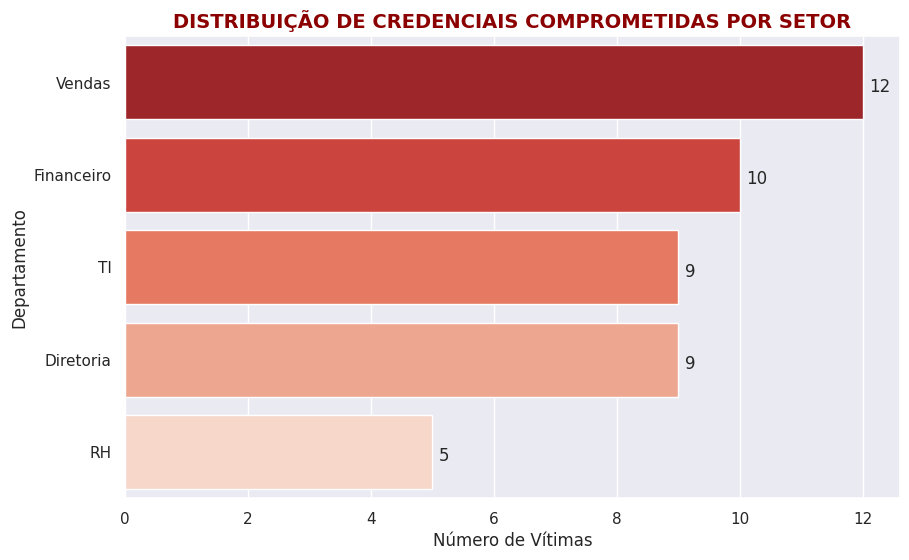

In [17]:
# @title 3. Dashboard de Comprometimento
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual
plt.figure(figsize=(10, 6))
sns.set_theme(style="darkgrid")

# Criar gráfico de barras por setor
ax = sns.countplot(y="Setor", data=df_leaks, order=df_leaks['Setor'].value_counts().index, palette="Reds_r")

plt.title('DISTRIBUIÇÃO DE CREDENCIAIS COMPROMETIDAS POR SETOR', fontsize=14, fontweight='bold', color='darkred')
plt.xlabel('Número de Vítimas')
plt.ylabel('Departamento')

# Adicionar números nas barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', (p.get_width() + 0.1, p.get_y() + 0.5))

plt.show()